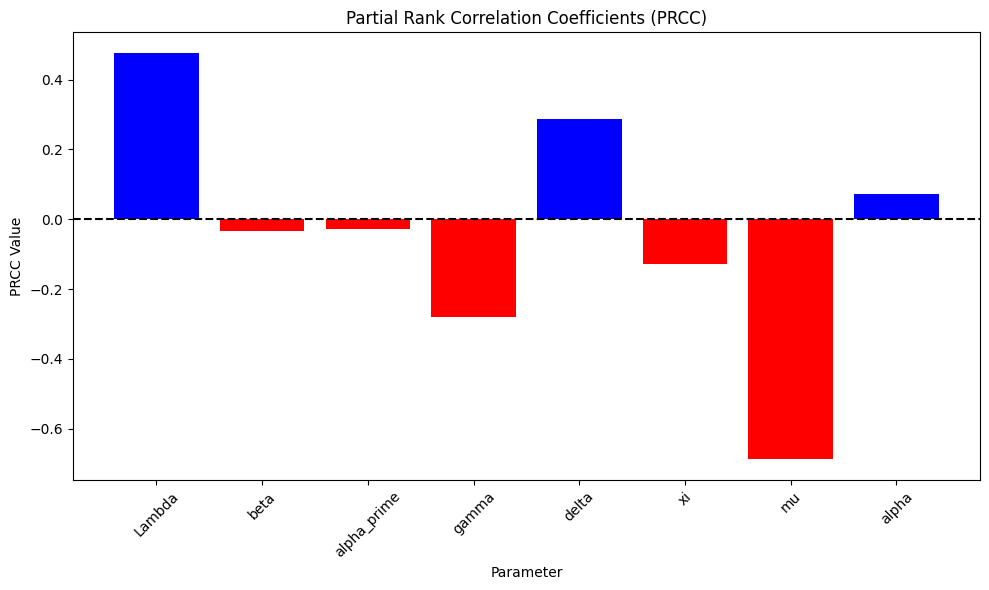

In [1]:
import numpy as np
import scipy.integrate as spi
from scipy.stats import spearmanr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Model definition
def cancer_model(y, t, Lambda, beta, alpha_prime, gamma, delta, xi, mu, alpha):
    S, I, C, R = y
    dSdt = Lambda - (beta * S * I) / (1 + alpha_prime * I) - mu * S + alpha * R
    dIdt = (beta * S * I) / (1 + alpha_prime * I) - gamma * I - delta * I - mu * I
    dCdt = delta * I - xi * C - mu * C
    dRdt = gamma * I - alpha * R - mu * R
    return [dSdt, dIdt, dCdt, dRdt]

# Latin Hypercube Sampling
def lhs_sampling(param_ranges, num_samples=100):
    num_params = len(param_ranges)
    lhs_samples = np.random.uniform(0, 1, (num_samples, num_params))
    scaled_params = np.array([
        lhs_samples[:, i] * (param_ranges[i][1] - param_ranges[i][0]) + param_ranges[i][0]
        for i in range(num_params)
    ]).T
    return scaled_params

# Parameter ranges from image
param_ranges = [
    (5, 40),       # Lambda
    (0.1, 1.0),    # beta
    (0.005, 0.02), # alpha_prime
    (0.01, 1.0),   # gamma
    (0.001, 0.6),  # delta
    (0.1, 0.25),   # xi
    (0.01, 0.8),   # mu
    (0.01, 0.2)    # alpha
]

# Parameter names
param_names = ['Lambda', 'beta', 'alpha_prime', 'gamma', 'delta', 'xi', 'mu', 'alpha']

# Sample parameters
num_samples = 100
samples = lhs_sampling(param_ranges, num_samples)

# Initial conditions
N = 1.0
init_conditions = [0.99*N, 0.01*N, 0.001*N, 0]
t = np.linspace(0, 500, 1000)

# Run simulations
endemic_C = []
for sample in samples:
    Lambda, beta, alpha_prime, gamma, delta, xi, mu, alpha = sample
    sol = spi.odeint(cancer_model, init_conditions, t, args=(Lambda, beta, alpha_prime, gamma, delta, xi, mu, alpha))
    endemic_C.append(sol[-1, 2])  # Final cancer level

# PRCC computation
prcc_values = [spearmanr(samples[:, i], endemic_C)[0] for i in range(len(param_names))]

# Plot PRCC results
colors = ['red' if val < 0 else 'blue' for val in prcc_values]
plt.figure(figsize=(10, 6))
plt.bar(param_names, prcc_values, color=colors)
plt.axhline(0, color='black', linestyle='dashed')
plt.ylabel('PRCC Value')
plt.xlabel('Parameter')
plt.title('Partial Rank Correlation Coefficients (PRCC)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
